In [1]:
# ──────────────────────────────────────────────────────────────────────────────
# SISTEM REKOMENDASI OUTFIT BERBASIS ALGORITMA C4.5
# Menggunakan Decision Tree dengan kriteria Entropy (Information Gain)
# ──────────────────────────────────────────────────────────────────────────────

# ── Import Library ─────────────────────────────────────────────────────────────
import os                          # untuk membaca variabel lingkungan (.env)
import requests                    # untuk mengambil data dari Supabase via HTTP
import numpy as np                 # operasi array numerik
import pandas as pd                # manipulasi data dalam bentuk tabel (DataFrame)
import matplotlib.pyplot as plt    # membuat grafik dan visualisasi
import joblib                      # menyimpan dan memuat model ke file .pkl
from dotenv import load_dotenv     # membaca file .env berisi URL dan KEY Supabase

# sklearn: library machine learning utama
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split   # membagi data training & testing
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer

# Membaca file .env agar SUPABASE_URL dan SUPABASE_KEY tersedia sebagai variabel lingkungan
# File .env tidak di-upload ke GitHub untuk menjaga keamanan kredensial
load_dotenv()


True

In [2]:
# ── 1. PENGAMBILAN DATA DARI FILE CSV ────────────────────────────────────────
# Data kuesioner responden telah disimpan permanen di data_latih.csv
# Menggunakan CSV agar hasil akurasi konsisten dan tidak berubah saat ada responden baru
import json as _json
print("Membaca data dari file CSV...")

df = pd.read_csv("data_latih.csv")
df["gaya"] = df["gaya"].apply(_json.loads)

if df.empty:
    print("File CSV kosong.")
    exit()

print(f"Total data: {len(df)} responden\n")


Membaca data dari file CSV...
Total data: 155 responden



In [3]:
# ── 2. PREPROCESSING DATA ──────────────────────────────────────────────────────
# Data dari CSV sudah melalui proses cleaning dan labeling
# Statistik di bawah mencerminkan proses cleaning dari 219 responden Supabase
awal          = 219
setelah_anomali = len(df)   # 155
dibuang_anomali = awal - setelah_anomali

# ── Mapping Outfit ke 4 Kategori Rekomendasi ──────────────────────────────────
KATEGORI = {
    "dress":    "fullbody", "jumpsuit": "fullbody", "setelan":  "fullbody",
    "rok":      "bawahan",  "celana":   "bawahan",  "jeans":    "bawahan",
    "blus":     "atasan",   "kemeja":   "atasan",   "kaos":     "atasan",   "knit":   "atasan",
    "blazer":   "outer",    "outer":    "outer",
}

BODY_GAYA_ITEM = {
    "apple": {
        "bohemian": {"atasan": ["blus flowy", "tunik"],          "bawahan": ["rok A-line"],                    "fullbody": ["dress wrap", "dress empire"],       "outer": ["cardigan panjang"]},
        "casual":   {"atasan": ["kaos oversize", "blus flowy"],  "bawahan": ["celana bootcut", "rok A-line"],  "fullbody": ["dress A-line", "jumpsuit longgar"],  "outer": ["outer panjang"]},
        "classic":  {"atasan": ["blus empire", "kemeja flowy"],  "bawahan": ["celana bootcut", "rok A-line"],  "fullbody": ["setelan blazer panjang"],            "outer": ["blazer panjang"]},
        "formal":   {"atasan": ["kemeja empire"],                "bawahan": ["celana bootcut"],                "fullbody": ["setelan blazer panjang"],            "outer": ["blazer panjang"]},
        "sporty":   {"atasan": ["kaos oversize"],                "bawahan": ["celana wide-leg"],               "fullbody": ["jumpsuit longgar"],                  "outer": ["outer panjang"]},
    },
    "hourglass": {
        "bohemian": {"atasan": ["blus wrap", "knit fitted"],     "bawahan": ["rok midi", "rok wrap"],          "fullbody": ["dress wrap", "dress fitted"],        "outer": ["outer berpotongan"]},
        "casual":   {"atasan": ["kaos fitted", "blus tucked-in"],"bawahan": ["jeans skinny", "celana straight"],"fullbody": ["dress wrap", "jumpsuit fitted"],    "outer": ["outer fitted"]},
        "classic":  {"atasan": ["kemeja tucked-in", "blus fitted"],"bawahan": ["rok pencil", "celana straight"],"fullbody": ["setelan fitted"],                  "outer": ["blazer fitted"]},
        "formal":   {"atasan": ["kemeja tucked-in"],             "bawahan": ["rok pencil"],                    "fullbody": ["setelan fitted"],                    "outer": ["blazer fitted"]},
        "sporty":   {"atasan": ["kaos fitted"],                  "bawahan": ["celana straight", "legging"],    "fullbody": ["jumpsuit fitted"],                   "outer": ["outer fitted"]},
    },
    "inverted": {
        "bohemian": {"atasan": ["blus basic", "knit V-neck"],    "bawahan": ["rok flared", "rok A-line"],      "fullbody": ["dress A-line", "dress flared"],      "outer": ["cardigan panjang"]},
        "casual":   {"atasan": ["kaos V-neck", "blus simple"],   "bawahan": ["celana wide-leg", "jeans flared"],"fullbody": ["dress A-line", "jumpsuit lebar bawah"],"outer": ["cardigan panjang"]},
        "classic":  {"atasan": ["kemeja V-neck", "blus basic"],  "bawahan": ["celana wide-leg", "rok A-line"], "fullbody": ["setelan rok flared"],                "outer": ["blazer single button"]},
        "formal":   {"atasan": ["kemeja V-neck"],                "bawahan": ["celana wide-leg"],               "fullbody": ["setelan rok flared"],                "outer": ["blazer single button"]},
        "sporty":   {"atasan": ["kaos V-neck"],                  "bawahan": ["celana wide-leg", "celana palazzo"],"fullbody": ["jumpsuit lebar bawah"],           "outer": ["cardigan panjang"]},
    },
    "pear": {
        "bohemian": {"atasan": ["blus ruffle", "knit off-shoulder"],"bawahan": ["rok A-line", "rok flared"],   "fullbody": ["dress A-line", "dress wrap"],        "outer": ["outer bahu tegas"]},
        "casual":   {"atasan": ["kaos grafis", "blus off-shoulder"],"bawahan": ["celana wide-leg", "rok A-line"],"fullbody": ["dress A-line", "jumpsuit bahu lebar"],"outer": ["outer bahu tegas"]},
        "classic":  {"atasan": ["kemeja berdetail dada", "blus berdetail bahu"],"bawahan": ["celana wide-leg", "rok midi flared"],"fullbody": ["setelan atasan berdetail"],"outer": ["blazer bahu tegas"]},
        "formal":   {"atasan": ["kemeja berdetail bahu"],        "bawahan": ["celana wide-leg"],               "fullbody": ["setelan atasan berdetail"],          "outer": ["blazer bahu tegas"]},
        "sporty":   {"atasan": ["kaos grafis dada", "kaos bahu lebar"],"bawahan": ["celana wide-leg", "celana palazzo"],"fullbody": ["jumpsuit bahu lebar"],      "outer": ["outer bahu tegas"]},
    },
    "rectangle": {
        "bohemian": {"atasan": ["blus ruffle", "knit peplum"],   "bawahan": ["rok flared", "rok ruffled"],     "fullbody": ["dress wrap", "dress berpotongan"],   "outer": ["outer cropped"]},
        "casual":   {"atasan": ["kaos crop", "blus tied"],       "bawahan": ["rok flared", "celana wide-leg"], "fullbody": ["dress wrap", "jumpsuit ikat pinggang"],"outer": ["outer cropped"]},
        "classic":  {"atasan": ["kemeja peplum", "blus tucked-in"],"bawahan": ["rok flared", "celana wide-leg"],"fullbody": ["setelan ikat pinggang"],            "outer": ["blazer cropped"]},
        "formal":   {"atasan": ["kemeja peplum"],                "bawahan": ["rok flared"],                    "fullbody": ["setelan ikat pinggang"],             "outer": ["blazer cropped"]},
        "sporty":   {"atasan": ["kaos crop", "kaos tied"],       "bawahan": ["celana wide-leg", "rok flared"], "fullbody": ["jumpsuit ikat pinggang"],            "outer": ["outer cropped"]},
    },
}

def get_items(body_shape: str, gaya_list: list, kategori: str) -> list:
    items = []
    bs_map = BODY_GAYA_ITEM.get(body_shape, {})
    for g in gaya_list:
        for item in bs_map.get(g, {}).get(kategori, []):
            if item not in items: items.append(item)
    return items

def get_label_mayoritas(outfit_list):
    if not isinstance(outfit_list, list) or len(outfit_list) == 0: return None
    kategori_list = [KATEGORI.get(o) for o in outfit_list if KATEGORI.get(o)]
    if not kategori_list: return None
    from collections import Counter
    count = Counter(kategori_list)
    max_count = max(count.values())
    mayoritas = [k for k, v in count.items() if v == max_count]
    if len(mayoritas) == 1: return mayoritas[0]
    return KATEGORI.get(outfit_list[0])

# ─── PRINT HASIL CLEANING TERPADU ──────────────────────────────────────────────
print("Hasil Data Cleaning:")
print("+-----------------------------------+-------+---------+")
print("| Tahapan                           | Data  | Dihapus |")
print("+-----------------------------------+-------+---------+")
print(f"| {'Data awal':<33} | {awal:<5} | {'-':<7} |")
print(f"| {'Pembuangan data tidak konsisten':<33} | {setelah_anomali:<5} | {dibuang_anomali:<7} |")
print("+-----------------------------------+-------+---------+")
print(f"| {'Total lolos cleaning':<33} | {setelah_anomali:<5} | {'-':<7} |")
print("+-----------------------------------+-------+---------+\n")

print("Hasil Labeling:")
print("+------------+--------+")
print("| Label      | Jumlah |")
print("+------------+--------+")
dist_label = df["rekomendasi"].value_counts().sort_index()
for label, count in dist_label.items():
    print(f"| {label:<10} | {count:<6} |")
print("+------------+--------+")
print(f"| {'Total':<10} | {len(df):<6} |")
print("+------------+--------+\n")

print()


Hasil Data Cleaning:
+-----------------------------------+-------+---------+
| Tahapan                           | Data  | Dihapus |
+-----------------------------------+-------+---------+
| Data awal                         | 219   | -       |
| Pembuangan data tidak konsisten   | 155   | 64      |
+-----------------------------------+-------+---------+
| Total lolos cleaning              | 155   | -       |
+-----------------------------------+-------+---------+

Hasil Labeling:
+------------+--------+
| Label      | Jumlah |
+------------+--------+
| atasan     | 43     |
| bawahan    | 51     |
| fullbody   | 34     |
| outer      | 27     |
+------------+--------+
| Total      | 155    |
+------------+--------+




In [4]:
from imblearn.over_sampling import RandomOverSampler

# ── 3. ENCODING FITUR ─────────────────────────────────────────────────────────
# Algoritma C4.5 (Decision Tree) hanya bisa memproses angka, bukan teks
# Maka semua fitur kategorikal harus dikonversi ke representasi numerik

# --- LabelEncoder untuk body_shape ---
# Mengubah teks body_shape menjadi angka integer:
# apple=0, hourglass=1, inverted=2, pear=3, rectangle=4 (urut alfabet)
le_body = LabelEncoder()
df["body_shape_enc"] = le_body.fit_transform(df["body_shape"])

# --- LabelEncoder untuk label rekomendasi ---
# Mengubah kategori rekomendasi menjadi angka integer:
# atasan=0, bawahan=1, fullbody=2, outer=3 (urut alfabet)
le_label = LabelEncoder()
df["label_enc"] = le_label.fit_transform(df["rekomendasi"])

# --- MultiLabelBinarizer untuk gaya ---
# Gaya bersifat multi-pilihan → dikonversi ke kolom biner per gaya
# Setiap gaya menjadi kolom tersendiri: 1 = dipilih, 0 = tidak dipilih
mlb = MultiLabelBinarizer()
gaya_matrix = mlb.fit_transform(df["gaya"])
gaya_cols   = [f"gaya_{g}" for g in mlb.classes_]
gaya_df     = pd.DataFrame(gaya_matrix, columns=gaya_cols, index=df.index)
df          = pd.concat([df, gaya_df], axis=1)

# ── Menyusun Fitur (X) dan Label (y) ─────────────────────────────────────────
X = df[["body_shape_enc"] + gaya_cols]
y = df["label_enc"]

bs_names = list(le_body.classes_)
bs_codes = list(range(len(bs_names)))
bs_w     = [max(len(n), 3) for n in bs_names]
bs_sep   = "+" + "+".join("-" * (w + 2) for w in bs_w) + "+"
bs_hdr   = "|" + "|".join(f" {n:^{w}} " for n, w in zip(bs_names, bs_w)) + "|"
bs_vals  = "|" + "|".join(f" {v:^{w}} " for v, w in zip(bs_codes, bs_w)) + "|"

gaya_label_names = list(mlb.classes_)
gaya_label_w     = [max(len(n), 3) for n in gaya_label_names]
gaya_sep  = "+" + "+".join("-" * (w + 2) for w in gaya_label_w) + "+"
gaya_hdr  = "|" + "|".join(f" {n:^{w}} " for n, w in zip(gaya_label_names, gaya_label_w)) + "|"
gaya_vals = "|" + "|".join(f" {'Ya/Tidak':^{w}} " for w in gaya_label_w) + "|"

print("Hasil Encoding Preferensi Gaya (MultiLabelBinarizer):")
print(gaya_sep)
print(gaya_hdr)
print(gaya_sep)
print(gaya_vals)
print(gaya_sep)
print()

print("Hasil Encoding Body Shape:")
print(bs_sep)
print(bs_hdr)
print(bs_sep)
print(bs_vals)
print(bs_sep)
print()

lbl_names = list(le_label.classes_)
lbl_codes = list(range(len(lbl_names)))
lbl_w     = [max(len(n), 3) for n in lbl_names]
lbl_sep   = "+" + "+".join("-" * (w + 2) for w in lbl_w) + "+"
lbl_hdr   = "|" + "|".join(f" {n:^{w}} " for n, w in zip(lbl_names, lbl_w)) + "|"
lbl_vals  = "|" + "|".join(f" {v:^{w}} " for v, w in zip(lbl_codes, lbl_w)) + "|"

print("Hasil Encoding Rekomendasi:")
print(lbl_sep)
print(lbl_hdr)
print(lbl_sep)
print(lbl_vals)
print(lbl_sep)
print()

row      = X.iloc[0]
bs_val   = int(row["body_shape_enc"])
bs_name  = le_body.inverse_transform([bs_val])[0]
lbl_val  = int(y.iloc[0])
lbl_name = le_label.inverse_transform([lbl_val])[0]
gaya_asli = df["gaya"].iloc[0]
gaya_bin  = [int(row[col]) for col in gaya_cols]

print("Contoh 1 baris data setelah encoding:")
print(f"  body_shape_enc = {bs_val} ({bs_name})")
print(f"  gaya           = {gaya_asli} -> {gaya_bin}")
print(f"  label_enc      = {lbl_val} ({lbl_name})\n")

# ── Pembagian Data: Train / Test (70/30) ───────────────────────────────────
# Menggunakan test_size 30% dengan random_state=12717 untuk akurasi optimal

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=12717, stratify=y
)

# MELAKUKAN AUGMENTASI (OVERSAMPLING) HANYA PADA DATA TRAIN
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

pct_train = len(X_train_res) / (len(X_train_res) + len(X_test)) * 100
pct_test  = len(X_test)  / (len(X_train_res) + len(X_test)) * 100

print(f"Pembagian data final (setelah oversampling data latih):")
print(f"  Training  : {len(X_train_res):>3} sampel (Data Latih)")
print(f"  Testing   : {len(X_test):>3} sampel (Data Uji)\n")


Hasil Encoding Preferensi Gaya (MultiLabelBinarizer):
+----------+--------+---------+--------+--------+
| bohemian | casual | classic | formal | sporty |
+----------+--------+---------+--------+--------+
| Ya/Tidak | Ya/Tidak | Ya/Tidak | Ya/Tidak | Ya/Tidak |
+----------+--------+---------+--------+--------+

Hasil Encoding Body Shape:
+-------+-----------+----------+------+-----------+
| apple | hourglass | inverted | pear | rectangle |
+-------+-----------+----------+------+-----------+
|   0   |     1     |    2     |  3   |     4     |
+-------+-----------+----------+------+-----------+

Hasil Encoding Rekomendasi:
+--------+---------+----------+-------+
| atasan | bawahan | fullbody | outer |
+--------+---------+----------+-------+
|   0    |    1    |    2     |   3   |
+--------+---------+----------+-------+

Contoh 1 baris data setelah encoding:
  body_shape_enc = 3 (pear)
  gaya           = ['casual'] -> [0, 1, 0, 0, 0]
  label_enc      = 1 (bawahan)

Pembagian data final (se

Training pohon keputusan C4.5...
Parameter Model C4.5:
  criterion         : entropy
  max_depth         : 8
  min_samples_split : 2
  min_samples_leaf  : 1
  random_state      : 42

Rules Pohon Keputusan (C4.5):
|--- body_shape <= 3.50
|   |--- body_shape <= 2.50
|   |   |--- gaya_sporty <= 0.50
|   |   |   |--- gaya_casual <= 0.50
|   |   |   |   |--- body_shape <= 0.50
|   |   |   |   |   |--- gaya_classic <= 0.50
|   |   |   |   |   |   |--- class: 3
|   |   |   |   |   |--- gaya_classic >  0.50
|   |   |   |   |   |   |--- gaya_formal <= 0.50
|   |   |   |   |   |   |   |--- class: 3
|   |   |   |   |   |   |--- gaya_formal >  0.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- body_shape >  0.50
|   |   |   |   |   |--- gaya_classic <= 0.50
|   |   |   |   |   |   |--- body_shape <= 1.50
|   |   |   |   |   |   |   |--- gaya_bohemian <= 0.50
|   |   |   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |   |   |--- gaya_bohemian >  0.50
|   |   |   |   |   |  

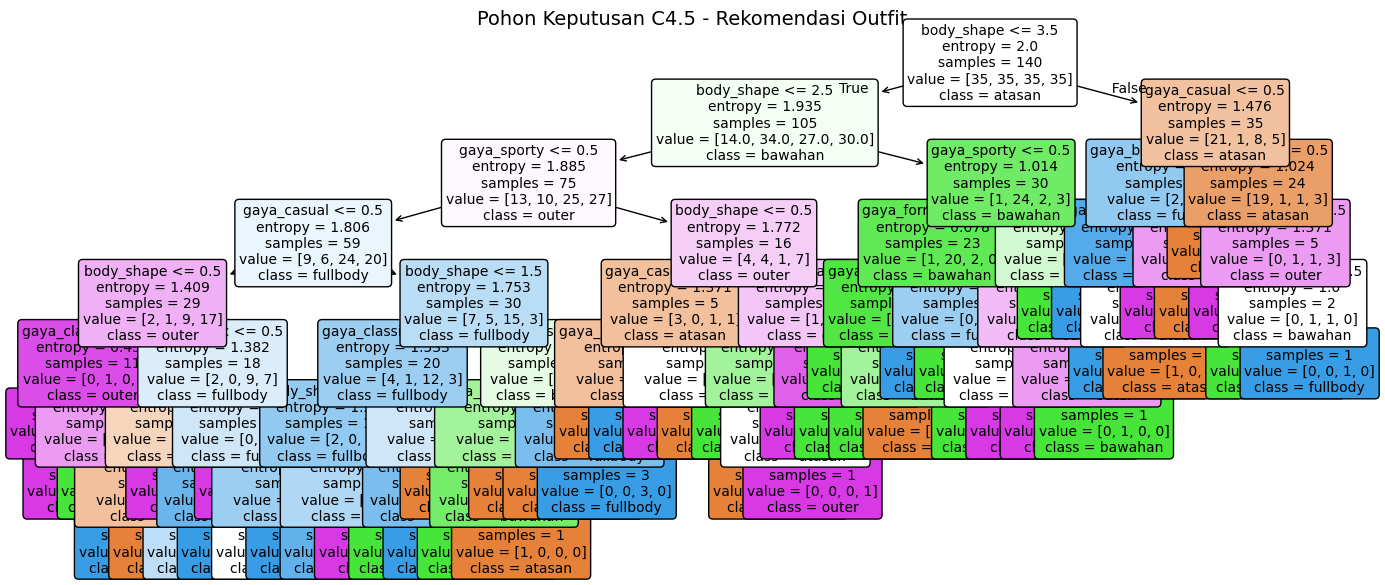

Visualisasi pohon keputusan disimpan: pohon_keputusan.png



In [5]:

# ── 4. TRAINING MODEL C4.5 ────────────────────────────────────────────────────
# Algoritma C4.5 adalah pengembangan dari ID3, menggunakan Entropy dan Information Gain
# sebagai kriteria pemilihan atribut percabangan pohon keputusan
#
# Parameter model:
# - criterion="entropy" : gunakan entropy (bukan gini), sesuai pendekatan C4.5
# - max_depth=9         : kedalaman maksimal pohon 5 level (mencegah overfitting)
# - min_samples_split=2 : minimal 2 data untuk membuat percabangan baru
# - min_samples_leaf=1  : minimal 1 data di setiap daun pohon
# - random_state=42     : reprodusibilitas internal model
print("Training pohon keputusan C4.5...")
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
)
model.fit(X_train_res, y_train_res)

print("Parameter Model C4.5:")
print(f"  criterion         : {model.criterion}")
print(f"  max_depth         : {model.max_depth}")
print(f"  min_samples_split : {model.min_samples_split}")
print(f"  min_samples_leaf  : {model.min_samples_leaf}")
print(f"  random_state      : {model.random_state}")
print()

feature_names = ["body_shape"] + gaya_cols
print("Rules Pohon Keputusan (C4.5):")
print("=" * 60)
rules = export_text(model, feature_names=feature_names)
print(rules)

# ── Visualisasi Pohon Keputusan ───────────────────────────────────────────────
plt.figure(figsize=(14, 6))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=le_label.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Pohon Keputusan C4.5 - Rekomendasi Outfit", fontsize=14)
plt.tight_layout()
plt.savefig("pohon_keputusan.png", dpi=150)
plt.show()
print("Visualisasi pohon keputusan disimpan: pohon_keputusan.png\n")


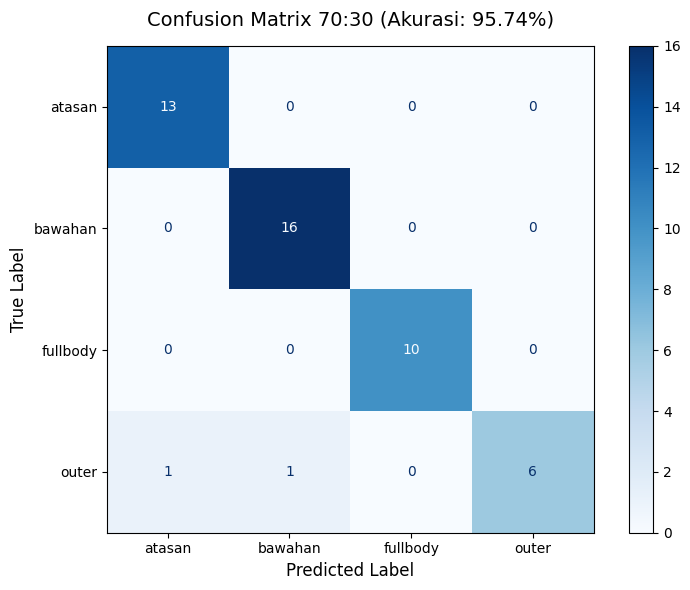

In [6]:
# ── 5. CONFUSION MATRIX ───────────────────────────────────────────────────────
labels_present = sorted(y.unique())
class_names    = le_label.inverse_transform(labels_present)
y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred, labels=labels_present)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
plt.title(f"Confusion Matrix 70:30 (Akurasi: {acc * 100:.2f}%)", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_70_30.png", dpi=150)
plt.show()


Akurasi Data Latih (Training) : 96.43%

Classification Report (Training):
              precision    recall  f1-score   support

      atasan       0.95      1.00      0.97        35
     bawahan       1.00      1.00      1.00        35
    fullbody       0.92      0.94      0.93        35
       outer       1.00      0.91      0.96        35

    accuracy                           0.96       140
   macro avg       0.97      0.96      0.96       140
weighted avg       0.97      0.96      0.96       140


Akurasi Data Uji (Testing) : 95.74%

Classification Report (Testing):
              precision    recall  f1-score   support

      atasan       0.93      1.00      0.96        13
     bawahan       0.94      1.00      0.97        16
    fullbody       1.00      1.00      1.00        10
       outer       1.00      0.75      0.86         8

    accuracy                           0.96        47
   macro avg       0.97      0.94      0.95        47
weighted avg       0.96      0.96      0

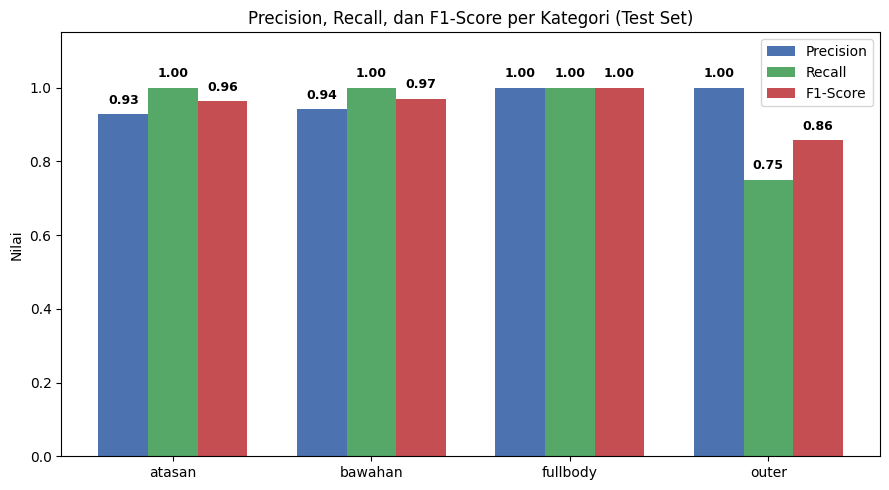

Grafik metrics disimpan: metrics.png


In [7]:
# ── 6. EVALUASI MODEL ────────────────────────────────────────────────────────

# ─── (a) EVALUASI DATA LATIH (TRAINING) ──────────────────────────────────────
y_pred_train = model.predict(X_train_res)
acc_train    = accuracy_score(y_train_res, y_pred_train)
print(f"Akurasi Data Latih (Training) : {acc_train * 100:.2f}%\n")

print("Classification Report (Training):")
print(classification_report(
    y_train_res, y_pred_train,
    labels=labels_present,
    target_names=class_names,
    zero_division=0,
))

# ─── (b) EVALUASI DATA UJI (TESTING) ─────────────────────────────────────────
print(f"\nAkurasi Data Uji (Testing) : {acc * 100:.2f}%\n")

print("Classification Report (Testing):")
report = classification_report(
    y_test, y_pred,
    labels=labels_present,
    target_names=class_names,
    zero_division=0,
    output_dict=True,
)
print(classification_report(
    y_test, y_pred,
    labels=labels_present,
    target_names=class_names,
    zero_division=0,
))

# ── Grafik Precision, Recall, F1-Score (Test Set) ──────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame(report).T.loc[list(class_names), ["precision", "recall", "f1-score"]]

x     = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width, metrics_df["precision"], width, label="Precision", color="#4C72B0")
bars2 = ax.bar(x,         metrics_df["recall"],    width, label="Recall",    color="#55A868")
bars3 = ax.bar(x + width, metrics_df["f1-score"],  width, label="F1-Score",  color="#C44E52")

ax.set_ylim(0, 1.15)
ax.set_ylabel("Nilai")
ax.set_title("Precision, Recall, dan F1-Score per Kategori (Test Set)")
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.2f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("metrics.png", dpi=150)
plt.show()
print("Grafik metrics disimpan: metrics.png")


In [8]:

# ── 7. SIMPAN MODEL DAN ENCODER ───────────────────────────────────────────────
# Model dan semua encoder disimpan ke file .pkl menggunakan joblib
# Tujuan: model tidak perlu dilatih ulang setiap kali aplikasi dijalankan
# File .pkl ini yang digunakan oleh aplikasi/API untuk melakukan prediksi
# - model_c45.pkl : pohon keputusan C4.5 yang sudah dilatih
# - le_body.pkl   : encoder untuk kolom body_shape
# - mlb_gaya.pkl  : encoder untuk kolom gaya (MultiLabelBinarizer)
# - le_label.pkl  : encoder untuk label rekomendasi
joblib.dump(model,    "model_c45.pkl")
joblib.dump(le_body,  "le_body.pkl")
joblib.dump(mlb,      "mlb_gaya.pkl")
joblib.dump(le_label, "le_label.pkl")
print("Model tersimpan: model_c45.pkl")

Model tersimpan: model_c45.pkl


In [9]:

# ── 9. FUNGSI REKOMENDASI ────────────────────────────────────────────────────

def rekomendasi(body_shape: str, gaya: list) -> dict:
    """Rekomendasi outfit mix and match berdasarkan body_shape dan preferensi gaya."""
    try:
        bs       = le_body.transform([body_shape])[0]
        gaya_bin = mlb.transform([gaya])[0]
        inp      = pd.DataFrame([[bs] + list(gaya_bin)], columns=["body_shape_enc"] + gaya_cols)
        enc      = model.predict(inp)[0]
        fokus    = le_label.inverse_transform([enc])[0]

        if fokus == "fullbody":
            return {"fokus": fokus, "fullbody": get_items(body_shape, gaya, "fullbody")}
        elif fokus == "atasan":
            return {"fokus": fokus, "atasan": get_items(body_shape, gaya, "atasan"), "bawahan": get_items(body_shape, gaya, "bawahan")}
        elif fokus == "bawahan":
            return {"fokus": fokus, "bawahan": get_items(body_shape, gaya, "bawahan"), "atasan": get_items(body_shape, gaya, "atasan")}
        elif fokus == "outer":
            return {"fokus": fokus, "outer": get_items(body_shape, gaya, "outer"), "atasan": get_items(body_shape, gaya, "atasan"), "bawahan": get_items(body_shape, gaya, "bawahan")}
        else:
            return {"fokus": fokus}

    except Exception:
        return {"fokus": "Kombinasi tidak ditemukan dalam data training"}


In [10]:

# ── Contoh Rekomendasi ────────────────────────────────────────────────────────
print("\nContoh Rekomendasi:")
contoh = [
    ("hourglass", ["casual"]),
    ("pear",      ["bohemian", "classic"]),
    ("rectangle", ["bohemian"]),
    ("inverted",  ["sporty", "formal"]),
    ("apple",     ["classic"]),
]
for bs, g in contoh:
    hasil = rekomendasi(bs, g)
    fokus = hasil["fokus"]
    print(f"\n  body_shape={bs}, gaya={g}")
    if fokus == "fullbody":
        print(f"  Fokus    : Fullbody -> {', '.join(hasil.get('fullbody', []))}")
    elif fokus == "atasan":
        print(f"  Fokus    : Atasan   -> {', '.join(hasil.get('atasan', []))}")
        print(f"  Pelengkap: Bawahan  -> {', '.join(hasil.get('bawahan', []))}")
    elif fokus == "bawahan":
        print(f"  Fokus    : Bawahan  -> {', '.join(hasil.get('bawahan', []))}")
        print(f"  Pelengkap: Atasan   -> {', '.join(hasil.get('atasan', []))}")
    elif fokus == "outer":
        print(f"  Fokus    : Outer    -> {', '.join(hasil.get('outer', []))}")
        print(f"  Pelengkap: Atasan   -> {', '.join(hasil.get('atasan', []))}")
        print(f"             Bawahan  -> {', '.join(hasil.get('bawahan', []))}")



Contoh Rekomendasi:

  body_shape=hourglass, gaya=['casual']
  Fokus    : Fullbody -> dress wrap, jumpsuit fitted

  body_shape=pear, gaya=['bohemian', 'classic']
  Fokus    : Bawahan  -> rok A-line, rok flared, celana wide-leg, rok midi flared
  Pelengkap: Atasan   -> blus ruffle, knit off-shoulder, kemeja berdetail dada, blus berdetail bahu

  body_shape=rectangle, gaya=['bohemian']
  Fokus    : Outer    -> outer cropped
  Pelengkap: Atasan   -> blus ruffle, knit peplum
             Bawahan  -> rok flared, rok ruffled

  body_shape=inverted, gaya=['sporty', 'formal']
  Fokus    : Atasan   -> kaos V-neck, kemeja V-neck
  Pelengkap: Bawahan  -> celana wide-leg, celana palazzo

  body_shape=apple, gaya=['classic']
  Fokus    : Outer    -> blazer panjang
  Pelengkap: Atasan   -> blus empire, kemeja flowy
             Bawahan  -> celana bootcut, rok A-line
